In [1]:
import pandas as pd
df=pd.read_csv("spam_classifier_dataset.csv")
df

,Unnamed: 0,label,message
0,0,ham,"Go until jurong point, crazy.. Available only ..."
1,1,ham,Ok lar... Joking wif u oni...
2,2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,3,ham,U dun say so early hor... U c already then say...
4,4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...,...
5567,5567,spam,This is the 2nd time we have tried 2 contact u...
5568,5568,ham,Will Ì_ b going to esplanade fr home?
5569,5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,5570,ham,The guy did some bitching but I acted like i'd...


In [2]:
df.shape

(5572, 3)

In [3]:
df.dtypes

Unnamed: 0     int64
label         object
message       object
dtype: object

In [4]:
df.isnull().sum()

Unnamed: 0    0
label         0
message       0
dtype: int64

In [6]:
df.columns

Index(['Unnamed: 0', 'label', 'message'], dtype='object')

In [7]:
df.label.value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

<Axes: xlabel='label'>

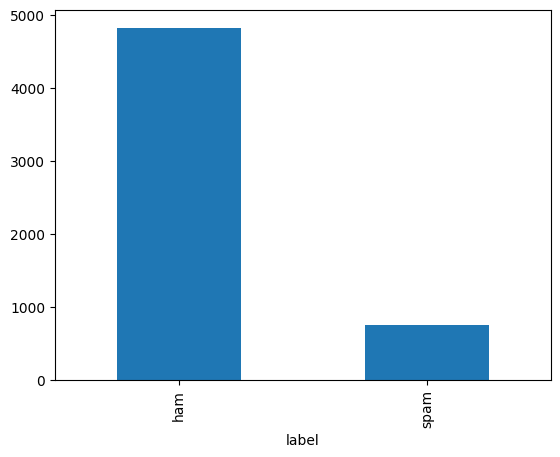

In [8]:
df.label.value_counts().plot(kind='bar')

In [9]:
df.message

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                Will Ì_ b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: message, Length: 5572, dtype: object

In [11]:
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+www\S+", "", text)
    text = re.sub(r'[^a-z\s]', "", text)
    return text

In [13]:
df.message

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                Will Ì_ b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: message, Length: 5572, dtype: object

In [15]:
df.message = df.message.apply(clean_text)

In [16]:
df.head()

,Unnamed: 0,label,message
0,0,ham,go until jurong point crazy available only in ...
1,1,ham,ok lar joking wif u oni
2,2,spam,free entry in a wkly comp to win fa cup final...
3,3,ham,u dun say so early hor u c already then say
4,4,ham,nah i dont think he goes to usf he lives aroun...


In [17]:
label_map = {
    "ham":0,"spam":1
}
df.label = df.label.map(label_map)

In [18]:
df.head()

,Unnamed: 0,label,message
0,0,0,go until jurong point crazy available only in ...
1,1,0,ok lar joking wif u oni
2,2,1,free entry in a wkly comp to win fa cup final...
3,3,0,u dun say so early hor u c already then say
4,4,0,nah i dont think he goes to usf he lives aroun...


In [19]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [20]:
df.head()

,label,message
0,0,go until jurong point crazy available only in ...
1,0,ok lar joking wif u oni
2,1,free entry in a wkly comp to win fa cup final...
3,0,u dun say so early hor u c already then say
4,0,nah i dont think he goes to usf he lives aroun...


In [23]:
x = df.message
y = df.label

In [24]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20
)

In [25]:
x

0       go until jurong point crazy available only in ...
1                                 ok lar joking wif u oni
2       free entry in  a wkly comp to win fa cup final...
3             u dun say so early hor u c already then say
4       nah i dont think he goes to usf he lives aroun...
                              ...                        
5567    this is the nd time we have tried  contact u u...
5568                   will  b going to esplanade fr home
5569    pity  was in mood for that soany other suggest...
5570    the guy did some bitching but i acted like id ...
5571                            rofl its true to its name
Name: message, Length: 5572, dtype: object

In [26]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(stop_words="english")

x_train = cv.fit_transform(x_train)
x_test = cv.transform(x_test)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(x_train, y_train)

In [28]:
y_pred = model.predict(x_test)

In [29]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9847533632286996

In [41]:
new_msg = "Congratulations! You have won ₹10,00,000. Claim now!"
new_msg = clean_text(new_msg)
new_msg

'congratulations you have won  claim now'

In [42]:
msg = cv.transform([new_msg])

In [43]:
pred = model.predict(msg)[0]
if pred == 1:
    print("Spam")
else:
    print("Ham")

Spam
